In [9]:
!apt-get install unrar



Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1).
0 upgraded, 0 newly installed, 0 to remove and 49 not upgraded.


In [10]:


# Extract the RAR file
!unrar x Dataset.rar



UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from Dataset.rar

Creating    PH2Dataset                                                OK
Extracting  PH2Dataset/PH2_dataset.txt                                     0%  OK 
Extracting  PH2Dataset/PH2_dataset.xlsx                                    0%  OK 
Extracting  PH2Dataset/Readme.txt                                          0%  OK 
Creating    PH2Dataset/PH2 Dataset images                             OK
Creating    PH2Dataset/PH2 Dataset images/IMD002                      OK
Creating    PH2Dataset/PH2 Dataset images/IMD002/IMD002_Dermoscopic_Image  OK
Extracting  PH2Dataset/PH2 Dataset images/IMD002/IMD002_Dermoscopic_Image/IMD002.bmp       0%  OK 
Creating    PH2Dataset/PH2 Dataset images/IMD002/IMD002_lesion        OK
Extracting  PH2Dataset/PH2 Dataset images/IMD002/IMD002_lesion/IMD002_lesion.bmp       0%  OK 
Creating    PH2Dataset/PH2 Dataset im

In [12]:
pip install tensorflow


In [13]:
pip install keras

## Importing the Libraries

In [14]:
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Activation, Dense, BatchNormalization, concatenate, Dropout, Conv2D,
    Conv2DTranspose, MaxPooling2D, UpSampling2D, Input, Reshape, SpatialDropout2D
)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
import numpy as np
import pandas as pd
import glob
from PIL import Image
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from warnings import filterwarnings

filterwarnings('ignore')
np.random.seed(101)


In [37]:
import os
import shutil
import random

# Set the paths for the dataset and the output directories
dataset_dir = 'PH2Dataset/PH2 Dataset images'
output_dir = 'PH2Dataset/split_data'
train_dir = os.path.join(output_dir, 'train')
test_dir = os.path.join(output_dir, 'test')

# Create directories for trainx and trainy
trainx_dir = os.path.join(train_dir, 'trainx')
trainy_dir = os.path.join(train_dir, 'trainy')
testx_dir = os.path.join(test_dir, 'testx')
testy_dir = os.path.join(test_dir, 'testy')

# Create the required directories
os.makedirs(trainx_dir, exist_ok=True)
os.makedirs(trainy_dir, exist_ok=True)
os.makedirs(testx_dir, exist_ok=True)
os.makedirs(testy_dir, exist_ok=True)

# Lists to hold file paths for dermoscopic and lesion images
dermoscopic_files = []
lesion_files = []

# Traverse the dataset directory
for folder in os.listdir(dataset_dir):
    folder_path = os.path.join(dataset_dir, folder)

    if os.path.isdir(folder_path):
        # Get the dermoscopic image
        dermoscopic_image_path = os.path.join(folder_path, f'{folder}_Dermoscopic_Image', f'{folder}.bmp')
        if os.path.exists(dermoscopic_image_path):
            dermoscopic_files.append(dermoscopic_image_path)

        # Get the lesion image
        lesion_image_path = os.path.join(folder_path, f'{folder}_lesion', f'{folder}_lesion.bmp')
        if os.path.exists(lesion_image_path):
            lesion_files.append(lesion_image_path)

# Combine dermoscopic and lesion files into a single list for splitting
combined_files = list(zip(dermoscopic_files, lesion_files))  # Create pairs of (dermoscopic, lesion)

# Shuffle files and split into train and test sets
random.shuffle(combined_files)
split_index = int(0.75 * len(combined_files))  # 75% for training
train_subset = combined_files[:split_index]
test_subset = combined_files[split_index:]

# Copy files to trainx and trainy directories
for dermoscopic_file, lesion_file in train_subset:
    shutil.copy(dermoscopic_file, os.path.join(trainx_dir, os.path.basename(dermoscopic_file)))
    shutil.copy(lesion_file, os.path.join(trainy_dir, os.path.basename(lesion_file)))

# Copy files to testx and testy directories
for dermoscopic_file, lesion_file in test_subset:
    shutil.copy(dermoscopic_file, os.path.join(testx_dir, os.path.basename(dermoscopic_file)))
    shutil.copy(lesion_file, os.path.join(testy_dir, os.path.basename(lesion_file)))

print(f"Total pairs: {len(combined_files)}")
print(f"Train dermoscopic images: {len(train_subset)}")
print(f"Test dermoscopic images: {len(test_subset)}")


Total pairs: 200
Train dermoscopic images: 150
Test dermoscopic images: 50


In [42]:
from PIL import Image
import numpy as np
import os

# Function to load images from a directory
def load_images_from_directory(directory):
    images = []
    for filename in os.listdir(directory):
        if filename.endswith('.bmp'):
            img_path = os.path.join(directory, filename)
            img = Image.open(img_path)
            images.append(np.array(img))  # Convert PIL Image to NumPy array
    return images

# Load train and test images
x_train = load_images_from_directory('PH2Dataset/split_data/train/trainx')
y_train = load_images_from_directory('PH2Dataset/split_data/train/trainy')
x_test = load_images_from_directory('PH2Dataset/split_data/test/testx')
y_test = load_images_from_directory('PH2Dataset/split_data/test/testy')




Train X images: 150
Train Y images: 150
Test X images: 50
Test Y images: 50


In [53]:
import glob
import numpy as np
from PIL import Image

# Define the target size for resizing
target_size = (128, 128)  # Example size, adjust as needed

# Function to load and resize images
def load_and_resize_images(file_list, target_size):
    images = []
    for fname in file_list:
        img = Image.open(fname)
        img = img.resize(target_size)  # Resize image
        images.append(np.array(img))    # Convert to NumPy array
    return np.array(images)

# Load and resize train images
filelist_trainx = sorted(glob.glob('/content/PH2Dataset/split_data/train/trainx/*.bmp'), key=numericalSort)
X_train = load_and_resize_images(filelist_trainx, target_size)

filelist_trainy = sorted(glob.glob('/content/PH2Dataset/split_data/train/trainy/*.bmp'), key=numericalSort)
Y_train = load_and_resize_images(filelist_trainy, target_size)

# Check shapes of the loaded arrays
print(f"X_train shape: {X_train.shape}")
print(f"Y_train shape: {Y_train.shape}")


X_train shape: (150, 128, 128, 3)
Y_train shape: (150, 128, 128)


In [55]:
x_train, x_test, y_train, y_test = train_test_split(X_train, Y_train, test_size = 0.25, random_state = 101)

## Loading the Data

Defining a function to load the data in sorted order

## Defining the Loss Function

#### Jaccard Distance  
The Jaccard distance, which measures dissimilarity between sample sets, is complementary to the Jaccard coefficient and is obtained by subtracting the Jaccard coefficient from 1, or, equivalently, by dividing the difference of the sizes of the union and the intersection of two sets by the size of the union:

![jd](https://www.geeksforgeeks.org/wp-content/ql-cache/quicklatex.com-44046533fcd54e98cb53619b3390e083_l3.svg)

In [85]:
import tensorflow as tf

def jaccard_distance(y_true, y_pred, smooth=100):
    # Use TensorFlow operations
    intersection = tf.reduce_sum(tf.abs(y_true * y_pred), axis=-1)
    sum_ = tf.reduce_sum(tf.square(y_true), axis=-1) + tf.reduce_sum(tf.square(y_pred), axis=-1)
    jac = (intersection + smooth) / (sum_ - intersection + smooth)
    return (1 - jac)


## Defining Evaluation Metrics

In [46]:
def precision(y_true, y_pred):
    '''Calculates the precision, a metric for multi-label classification of
    how many selected items are relevant.
    '''
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    return precision

#### Recall  
Recall actually calculates how many of the Actual Positives our model capture through labeling it as Positive (True Positive). Applying the same understanding, we know that Recall shall be the model metric we use to select our best model when there is a high cost associated with False Negative.


![recall](https://wikimedia.org/api/rest_v1/media/math/render/svg/4c233366865312bc99c832d1475e152c5074891b)

In [47]:
def recall(y_true, y_pred):
    '''Calculates the recall, a metric for multi-label classification of
    how many relevant items are selected.
    '''
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    recall = true_positives / (possible_positives + K.epsilon())
    return recall

#### Accuracy

In [48]:
def accuracy(y_true, y_pred):
    '''Calculates the mean accuracy rate across all predictions for binary
    classification problems.
    '''
    return K.mean(K.equal(y_true, K.round(y_pred)))

## Image Augmentation  
To build a powerful image classifier using very little training data, image augmentation is usually required to boost the performance of deep networks. Image augmentation artificially creates training images through different ways of processing or combination of multiple processing, such as random rotation, shifts, shear and flips, etc.

We are going to define to methods for augmentation, one for **random rotation** and one for **horizontal flipping**

In [56]:
def random_rotation(x_image, y_image):
    rows_x,cols_x, chl_x = x_image.shape
    rows_y,cols_y = y_image.shape
    rand_num = np.random.randint(-40,40)
    M1 = cv2.getRotationMatrix2D((cols_x/2,rows_x/2),rand_num,1)
    M2 = cv2.getRotationMatrix2D((cols_y/2,rows_y/2),rand_num,1)
    x_image = cv2.warpAffine(x_image,M1,(cols_x,rows_x))
    y_image = cv2.warpAffine(y_image.astype('float32'),M2,(cols_y,rows_y))
    return x_image, y_image.astype('int')

def horizontal_flip(x_image, y_image):
    x_image = cv2.flip(x_image, 1)
    y_image = cv2.flip(y_image.astype('float32'), 1)
    return x_image, y_image.astype('int')

In [57]:
def img_augmentation(x_train, y_train):
    x_rotat = []
    y_rotat = []
    x_flip = []
    y_flip = []
    for idx in range(len(x_train)):
        x,y = random_rotation(x_train[idx], y_train[idx])
        x_rotat.append(x)
        y_rotat.append(y)
        x,y = horizontal_flip(x_train[idx], y_train[idx])
        x_flip.append(x)
        y_flip.append(y)
    return np.array(x_rotat), np.array(y_rotat), np.array(x_flip), np.array(y_flip)

calling the functions for the training data.

In [58]:
x_rotated, y_rotated, x_flipped, y_flipped = img_augmentation(x_train, y_train)

Let us have a look at our transformations.

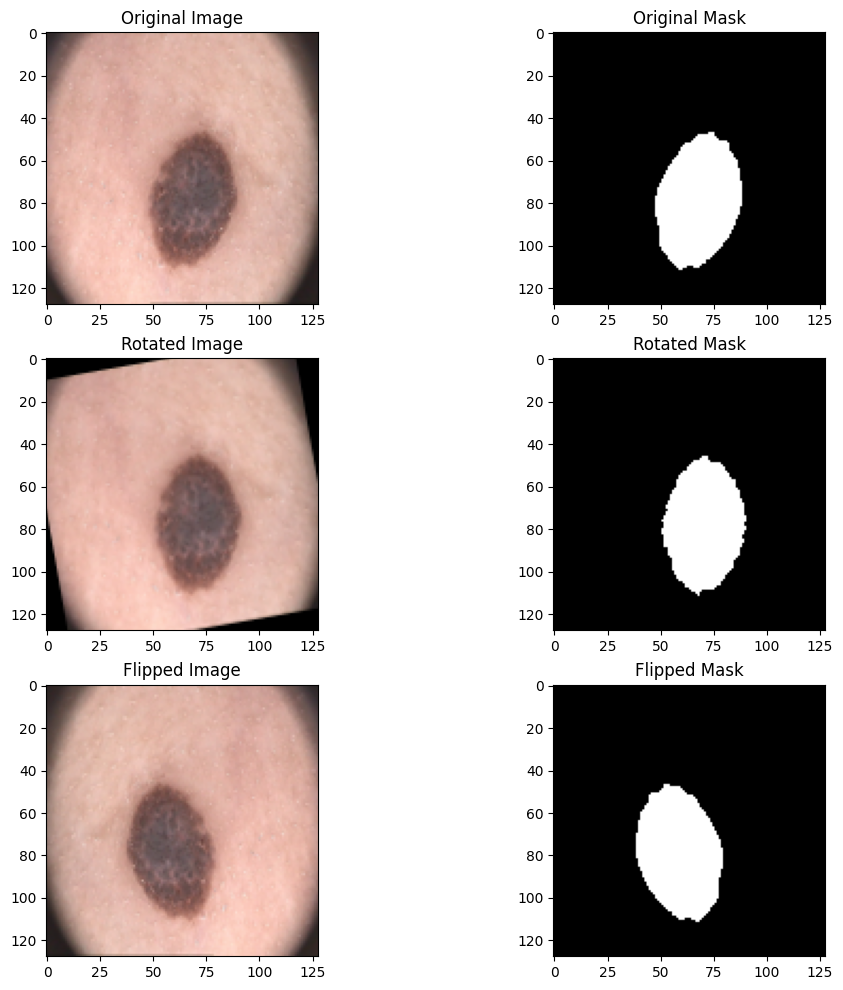

In [59]:
img_num = 7
plt.figure(figsize=(12,12))
plt.subplot(3,2,1)
plt.imshow(x_train[img_num])
plt.title('Original Image')
plt.subplot(3,2,2)
plt.imshow(y_train[img_num], plt.cm.binary_r)
plt.title('Original Mask')
plt.subplot(3,2,3)
plt.imshow(x_rotated[img_num])
plt.title('Rotated Image')
plt.subplot(3,2,4)
plt.imshow(y_rotated[img_num], plt.cm.binary_r)
plt.title('Rotated Mask')
plt.subplot(3,2,5)
plt.imshow(x_flipped[img_num])
plt.title('Flipped Image')
plt.subplot(3,2,6)
plt.imshow(y_flipped[img_num], plt.cm.binary_r)
plt.title('Flipped Mask')
plt.show()

Now we join all the augmentations image arrays to the original training arrays.

In [60]:
x_train_full = np.concatenate([x_train, x_rotated, x_flipped])
y_train_full = np.concatenate([y_train, y_rotated, y_flipped])

#### Making a Validation Set  
We will split our full training set into train and validation set.
Validation dataset is used to validate the performance after each epoch.

In [61]:
x_train, x_val, y_train, y_val = train_test_split(x_train_full, y_train_full, test_size = 0.20, random_state = 101)

In [62]:
print("Length of the Training Set   : {}".format(len(x_train)))
print("Length of the Test Set       : {}".format(len(x_test)))
print("Length of the Validation Set : {}".format(len(x_val)))

Length of the Training Set   : 268
Length of the Test Set       : 38
Length of the Validation Set : 68


## The Model

Defining the model in a function which takes two arguments when called
* **epoch_num**: number of epochs to run  
* **savename**: the name of the model for saving after training

#### Optimizer and Learning Rate  
* We adopt adam optimization algorithm or adaptive moments, to adjust the learning rate.   
* It is well known that learning rate is one of the critical hyperparameters that have a signiﬁcant impact on classiﬁcation performance.     
* Advantages of Adam optimizer are:
    - Relatively low memory requirements (though higher than gradient descent and gradient descent with momentum).
    - Usually works well even with a little tuning of hyperparameter
* Adam is fairly robust to the choice of hyperparameters, and set the learning rate **α** as 0.003 to speed up the training procedure in this study as advised in the paper [here](https://arxiv.org/pdf/1703.05165v2.pdf)

### Model Function

> ![arch](https://raw.githubusercontent.com/hashbanger/Skin_Lesion_Segmentation/master/graphics/unet_arch.png)

In [63]:
# Number of image channels (for example 3 in case of RGB, or 1 for grayscale images)
INPUT_CHANNELS = 3
# Number of output masks (1 in case you predict only one type of objects)
OUTPUT_MASK_CHANNELS = 1
# Pretrained weights


<font color='red'>**Problems In Guided Dropout Implementation**     
            
- The entire network architecture is implemented using Keras.  
- Now to implement the Guided Dropout Layer using Keras we have to know the detailed backend of the Keras Library because:  
- We should know in what form the inputs will be coming to our layer so we could manipulate them.  
- We should also know in what form the output should be given to the next layer.  
- If we implement Guided Dropout from scratch then we will have to implement entire architecture from scratch which will be neither efficient nor easily feasible.</font>

### For 1 epoch

In [100]:
import numpy as np
import pandas as pd
import glob
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from warnings import filterwarnings

# Ignore warnings
filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(101)

# TensorFlow and Keras imports
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Activation,
    Dense,
    BatchNormalization,
    concatenate,
    Dropout,
    Conv2D,
    Conv2DTranspose,
    MaxPooling2D,
    UpSampling2D,
    Input,
    Reshape,
    SpatialDropout2D
)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

# For inline plotting in Jupyter Notebooks
%matplotlib inline


In [105]:
from keras.models import Model
from keras.layers import Activation, Dense, BatchNormalization, concatenate, Dropout, Conv2D, UpSampling2D, Input
from keras.callbacks import EarlyStopping
from keras.layers import MaxPooling2D
from keras import backend as K
from keras.optimizers import Adam
import tensorflow as tf
import numpy as np

def double_conv_layer(x, size, dropout=0.40, batch_norm=True):
    # Use 'channels_last' by default
    conv = Conv2D(size, (3, 3), padding='same')(x)
    if batch_norm:
        conv = BatchNormalization()(conv)
    conv = Activation('relu')(conv)
    conv = Conv2D(size, (3, 3), padding='same')(conv)
    if batch_norm:
        conv = BatchNormalization()(conv)
    conv = Activation('relu')(conv)
    if dropout > 0:
        conv = Dropout(dropout)(conv)
    return conv

def UNET_128(epochs_num, savename):
    dropout_val = 0.50
    inputs = Input((128, 128, 3))  # Input shape updated to 128x128
    filters = 32

    conv_128 = double_conv_layer(inputs, filters)
    pool_64 = MaxPooling2D(pool_size=(2, 2))(conv_128)

    conv_64 = double_conv_layer(pool_64, 2 * filters)
    pool_32 = MaxPooling2D(pool_size=(2, 2))(conv_64)

    conv_32 = double_conv_layer(pool_32, 4 * filters)
    pool_16 = MaxPooling2D(pool_size=(2, 2))(conv_32)

    conv_16 = double_conv_layer(pool_16, 8 * filters)
    pool_8 = MaxPooling2D(pool_size=(2, 2))(conv_16)

    conv_8 = double_conv_layer(pool_8, 16 * filters)

    up_16 = concatenate([UpSampling2D(size=(2, 2))(conv_8), conv_16], axis=-1)
    up_conv_16 = double_conv_layer(up_16, 8 * filters)

    up_32 = concatenate([UpSampling2D(size=(2, 2))(up_conv_16), conv_32], axis=-1)
    up_conv_32 = double_conv_layer(up_32, 4 * filters)

    up_64 = concatenate([UpSampling2D(size=(2, 2))(up_conv_32), conv_64], axis=-1)
    up_conv_64 = double_conv_layer(up_64, 2 * filters)

    up_128 = concatenate([UpSampling2D(size=(2, 2))(up_conv_64), conv_128], axis=-1)
    up_conv_128 = double_conv_layer(up_128, filters, dropout_val)

    conv_final = Conv2D(1, (1, 1))(up_conv_128)  # Assuming binary segmentation output
    conv_final = Activation('sigmoid')(conv_final)

    model = Model(inputs, conv_final, name="UNET_128")
    model.compile(optimizer=Adam(learning_rate=0.003), loss='binary_crossentropy', metrics=['accuracy'])

    model.summary()
    hist = model.fit(x_train, y_train, epochs=epochs_num, batch_size=18, validation_data=(x_val, y_val), verbose=1)
    model.save(savename)
    return model, hist

# Example usage:
model, hist = UNET_128(1, 'unet_1_epoch.h5')


Model: "UNET_128"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11            │ (None, 128, 128, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_225 (Conv2D)       │ (None, 128, 128, 32)   │            896 │ input_layer_11[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_214   │ (None, 128, 128, 32)   │            128 │ conv2d_225[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_225            │ (None, 128, 128, 32)   │              0 │ batch_normalization_2… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_226 (Conv2D)       │ (None, 128, 128, 32)   │          9,248 │ activation_225[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_215   │ (None, 128, 128, 32)   │            128 │ conv2d_226[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_226            │ (None, 128, 128, 32)   │              0 │ batch_normalization_2… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_11 (Dropout)      │ (None, 128, 128, 32)   │              0 │ activation_226[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_48          │ (None, 64, 64, 32)     │              0 │ dropout_11[0][0]       │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_227 (Conv2D)       │ (None, 64, 64, 64)     │         18,496 │ max_pooling2d_48[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_216   │ (None, 64, 64, 64)     │            256 │ conv2d_227[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_227            │ (None, 64, 64, 64)     │              0 │ batch_normalization_2… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_228 (Conv2D)       │ (None, 64, 64, 64)     │         36,928 │ activation_227[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_217   │ (None, 64, 64, 64)     │            256 │ conv2d_228[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_228            │ (None, 64, 64, 64)     │              0 │ batch_normalization_2… │
│ (Activation)         

 Total params: 7,858,433 (29.98 MB)

 Trainable params: 7,852,545 (29.96 MB)

 Non-trainable params: 5,888 (23.00 KB)

15/15 ━━━━━━━━━━━━━━━━━━━━ 244s 15s/step - accuracy: 0.6947 - loss: 0.6036 - val_accuracy: 0.7335 - val_loss: 4.2954


## Loading the Model

Here we can load a pretrained model

In [106]:
from keras.models import Model
from keras.layers import Activation, BatchNormalization, concatenate, Dropout, Conv2D, UpSampling2D, Input, Reshape
from keras.layers import MaxPooling2D
from keras.optimizers import Adam
import tensorflow as tf

def double_conv_layer(x, size, dropout=0.40, batch_norm=True):
    conv = Conv2D(size, (3, 3), padding='same')(x)
    if batch_norm:
        conv = BatchNormalization()(conv)
    conv = Activation('relu')(conv)
    conv = Conv2D(size, (3, 3), padding='same')(conv)
    if batch_norm:
        conv = BatchNormalization()(conv)
    conv = Activation('relu')(conv)
    if dropout > 0:
        conv = Dropout(dropout)(conv)
    return conv

def UNET_128(epochs_num, savename):
    dropout_val = 0.50
    inputs = Input((128, 128, 3))  # Input size set to 128x128
    filters = 32

    conv_128 = double_conv_layer(inputs, filters)  # First layer
    pool_64 = MaxPooling2D(pool_size=(2, 2))(conv_128)

    conv_64 = double_conv_layer(pool_64, 2 * filters)  # Second layer
    pool_32 = MaxPooling2D(pool_size=(2, 2))(conv_64)

    conv_32 = double_conv_layer(pool_32, 4 * filters)  # Third layer
    pool_16 = MaxPooling2D(pool_size=(2, 2))(conv_32)

    conv_16 = double_conv_layer(pool_16, 8 * filters)  # Fourth layer
    pool_8 = MaxPooling2D(pool_size=(2, 2))(conv_16)

    conv_8 = double_conv_layer(pool_8, 16 * filters)  # Fifth layer

    # Up-sampling and concatenation
    up_16 = concatenate([UpSampling2D(size=(2, 2))(conv_8), conv_16], axis=-1)
    up_conv_16 = double_conv_layer(up_16, 8 * filters)

    up_32 = concatenate([UpSampling2D(size=(2, 2))(up_conv_16), conv_32], axis=-1)
    up_conv_32 = double_conv_layer(up_32, 4 * filters)

    up_64 = concatenate([UpSampling2D(size=(2, 2))(up_conv_32), conv_64], axis=-1)
    up_conv_64 = double_conv_layer(up_64, 2 * filters)

    up_128 = concatenate([UpSampling2D(size=(2, 2))(up_conv_64), conv_128], axis=-1)
    up_conv_128 = double_conv_layer(up_128, filters, dropout_val)

    # Final convolution
    conv_final = Conv2D(1, (1, 1))(up_conv_128)  # Assuming binary segmentation
    conv_final = Activation('sigmoid')(conv_final)
    pred = Reshape((128, 128))(conv_final)  # Output shape set to 128x128

    model = Model(inputs, pred, name="UNET_128")
    model.compile(optimizer=Adam(learning_rate=0.003), loss='binary_crossentropy', metrics=['accuracy'])

    model.summary()
    hist = model.fit(x_train, y_train, epochs=epochs_num, batch_size=18, validation_data=(x_val, y_val), verbose=1)
    model.save(savename)
    return model, hist

# Example usage:
model, hist = UNET_128(1, 'unet_1_epoch.h5')


Model: "UNET_128"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_12            │ (None, 128, 128, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_244 (Conv2D)       │ (None, 128, 128, 32)   │            896 │ input_layer_12[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_232   │ (None, 128, 128, 32)   │            128 │ conv2d_244[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_244            │ (None, 128, 128, 32)   │              0 │ batch_normalization_2… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_245 (Conv2D)       │ (None, 128, 128, 32)   │          9,248 │ activation_244[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_233   │ (None, 128, 128, 32)   │            128 │ conv2d_245[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_245            │ (None, 128, 128, 32)   │              0 │ batch_normalization_2… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_20 (Dropout)      │ (None, 128, 128, 32)   │              0 │ activation_245[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_52          │ (None, 64, 64, 32)     │              0 │ dropout_20[0][0]       │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_246 (Conv2D)       │ (None, 64, 64, 64)     │         18,496 │ max_pooling2d_52[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_234   │ (None, 64, 64, 64)     │            256 │ conv2d_246[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_246            │ (None, 64, 64, 64)     │              0 │ batch_normalization_2… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_247 (Conv2D)       │ (None, 64, 64, 64)     │         36,928 │ activation_246[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_235   │ (None, 64, 64, 64)     │            256 │ conv2d_247[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_247            │ (None, 64, 64, 64)     │              0 │ batch_normalization_2… │
│ (Activation)         

 Total params: 7,858,433 (29.98 MB)

 Trainable params: 7,852,545 (29.96 MB)

 Non-trainable params: 5,888 (23.00 KB)

15/15 ━━━━━━━━━━━━━━━━━━━━ 267s 16s/step - accuracy: 0.0177 - loss: 0.5866 - val_accuracy: 0.3686 - val_loss: 11.6938


#### After 100 epochs

In [110]:
# Define input shape and other configurations
INPUT_CHANNELS = 3  # Adjust according to your input image channels
OUTPUT_MASK_CHANNELS = 1  # Change to 1 for binary segmentation

# Define input layer based on your image data format
inputs = Input((128, 128, INPUT_CHANNELS))  # Changed input size to 128x128

# UNET model definition
dropout_val = 0.50
filters = 32

# Build the UNET architecture
conv_128 = double_conv_layer(inputs, filters)
pool_64 = MaxPooling2D(pool_size=(2, 2))(conv_128)

conv_64 = double_conv_layer(pool_64, 2 * filters)
pool_32 = MaxPooling2D(pool_size=(2, 2))(conv_64)

conv_32 = double_conv_layer(pool_32, 4 * filters)
pool_16 = MaxPooling2D(pool_size=(2, 2))(conv_32)

conv_16 = double_conv_layer(pool_16, 8 * filters)
pool_8 = MaxPooling2D(pool_size=(2, 2))(conv_16)

conv_8 = double_conv_layer(pool_8, 16 * filters)

up_16 = concatenate([UpSampling2D(size=(2, 2))(conv_8), conv_16], axis=-1)
up_conv_16 = double_conv_layer(up_16, 8 * filters)

up_32 = concatenate([UpSampling2D(size=(2, 2))(up_conv_16), conv_32], axis=-1)
up_conv_32 = double_conv_layer(up_32, 4 * filters)

up_64 = concatenate([UpSampling2D(size=(2, 2))(up_conv_32), conv_64], axis=-1)
up_conv_64 = double_conv_layer(up_64, 2 * filters)

up_128 = concatenate([UpSampling2D(size=(2, 2))(up_conv_64), conv_128], axis=-1)
up_conv_128 = double_conv_layer(up_128, filters, dropout_val)

# Output layer
conv_final = Conv2D(OUTPUT_MASK_CHANNELS, (1, 1))(up_conv_128)
pred = Activation('sigmoid')(conv_final)  # Use sigmoid for binary classification
pred = Reshape((128, 128, OUTPUT_MASK_CHANNELS))(pred)

# Create the model
model_0 = Model(inputs, pred, name="UNET_128")
model_0.compile(optimizer=Adam(learning_rate=0.003),
                 loss='binary_crossentropy',  # Using binary cross-entropy loss
                 metrics=['accuracy'])  # Only include accuracy as a metric

model_0.load_weights('unet_1_epoch.h5')

print('\n~~~~~~~~~~~~~~~Stats after 1 epoch~~~~~~~~~~~~~~~~~~~')
print('\n-------------On Train Set--------------------------\n')
res = model_0.evaluate(x_train, y_train, batch_size=18)
print('________________________')
print('Accuracy:  |   {:.2f}  |'.format(res[1] * 100))
print("Loss:      |   {:.2f}  |".format(res[0] * 100))
print('________________________')

print('\n-------------On Test Set--------------------------\n')
res = model_0.evaluate(x_test, y_test, batch_size=18)
print('________________________')
print('Accuracy:  |   {:.2f}  |'.format(res[1] * 100))
print("Loss:      |   {:.2f}  |".format(res[0] * 100))
print('________________________')

print('\n-------------On Validation Set---------------------\n')
res = model_0.evaluate(x_val, y_val, batch_size=18)
print('________________________')
print('Accuracy:  |   {:.2f}  |'.format(res[1] * 100))
print("Loss:      |   {:.2f}  |".format(res[0] * 100))
print('________________________')



~~~~~~~~~~~~~~~Stats after 1 epoch~~~~~~~~~~~~~~~~~~~

-------------On Train Set--------------------------

15/15 ━━━━━━━━━━━━━━━━━━━━ 48s 3s/step - accuracy: 0.3041 - loss: 11.0938
________________________
Accuracy:  |   30.05  |
Loss:      |   1115.19  |
________________________

-------------On Test Set--------------------------

3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.4080 - loss: 9.4374
________________________
Accuracy:  |   39.24  |
Loss:      |   968.69  |
________________________

-------------On Validation Set---------------------

4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step - accuracy: 0.2757 - loss: 11.5477
________________________
Accuracy:  |   26.65  |
Loss:      |   1169.38  |
________________________


In [ ]:
model, hist = UNET_128(epochs_num= 100, savename= 'unet_100_epoch.h5')

__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_3 (InputLayer)            (None, 224, 224, 3)  0                                            
__________________________________________________________________________________________________
conv2d_47 (Conv2D)              (None, 224, 224, 32) 896         input_3[0][0]                    
__________________________________________________________________________________________________
batch_normalization_45 (BatchNo (None, 224, 224, 32) 128         conv2d_47[0][0]                  
__________________________________________________________________________________________________
activation_47 (Activation)      (None, 224, 224, 32) 0           batch_normalization_45[0][0]     
__________________________________________________________________________________________________
conv2d_48 

In [ ]:
model_1 = Model(inputs, pred, name="UNET_224")
model_1.compile(optimizer= Adam(lr = 0.003), loss= [jaccard_distance]
                  , metrics=[iou, dice_coe, precision, recall, accuracy])


In [ ]:
model_1.load_weights('unet_100_epoch.h5')

![](http://)Testing the statistics after 100 epochs

In [ ]:

print('\n~~~~~~~~~~~~~~~Stats after 100 epoch~~~~~~~~~~~~~~~~~~~')
print('\n-------------On Train Set--------------------------\n')
res = model_1.evaluate(x_train, y_train, batch_size= 18)
print('________________________')
print('IOU:       |   {:.2f}  |'.format(res[1]*100))
print('Dice Coef: |   {:.2f}  |'.format(res[2]*100))
print('Precision: |   {:.2f}  |'.format(res[3]*100))
print('Recall:    |   {:.2f}  |'.format(res[4]*100))
print('Accuracy:  |   {:.2f}  |'.format(res[5]*100))
print("Loss:      |   {:.2f}  |".format(res[0]*100))
print('________________________')
print('\n-------------On Test  Set--------------------------\n')
res = model_1.evaluate(x_test, y_test, batch_size= 18)
print('________________________')
print('IOU:       |   {:.2f}  |'.format(res[1]*100))
print('Dice Coef: |   {:.2f}  |'.format(res[2]*100))
print('Precision: |   {:.2f}  |'.format(res[3]*100))
print('Recall:    |   {:.2f}  |'.format(res[4]*100))
print('Accuracy:  |   {:.2f}  |'.format(res[5]*100))
print("Loss:      |   {:.2f}  |".format(res[0]*100))
print('________________________')
print('\n-------------On validation Set---------------------\n')
res = model_1.evaluate(x_val, y_val, batch_size= 18)
print('________________________')
print('IOU:       |   {:.2f}  |'.format(res[1]*100))
print('Dice Coef: |   {:.2f}  |'.format(res[2]*100))
print('Precision: |   {:.2f}  |'.format(res[3]*100))
print('Recall:    |   {:.2f}  |'.format(res[4]*100))
print('Accuracy:  |   {:.2f}  |'.format(res[5]*100))
print("Loss:      |   {:.2f}  |".format(res[0]*100))
print('________________________')


~~~~~~~~~~~~~~~Stats after 100 epoch~~~~~~~~~~~~~~~~~~~

-------------On Train Set--------------------------

360/360 [==============================] - 3s 9ms/step
________________________
IOU:       |   94.92  |
Dice Coef: |   89.58  |
Precision: |   87.83  |
Recall:    |   96.30  |
Accuracy:  |   94.55  |
Loss:      |   5.08  |
________________________

-------------On Test  Set--------------------------

50/50 [==============================] - 0s 5ms/step
________________________
IOU:       |   93.85  |
Dice Coef: |   87.95  |
Precision: |   84.86  |
Recall:    |   95.95  |
Accuracy:  |   93.57  |
Loss:      |   6.15  |
________________________

-------------On validation Set---------------------

90/90 [==============================] - 0s 5ms/step
________________________
IOU:       |   94.81  |
Dice Coef: |   89.19  |
Precision: |   86.24  |
Recall:    |   96.81  |
Accuracy:  |   94.18  |
Loss:      |   5.19  |
________________________


### Plotting Training Stats

## Visualising Predicted Lesions

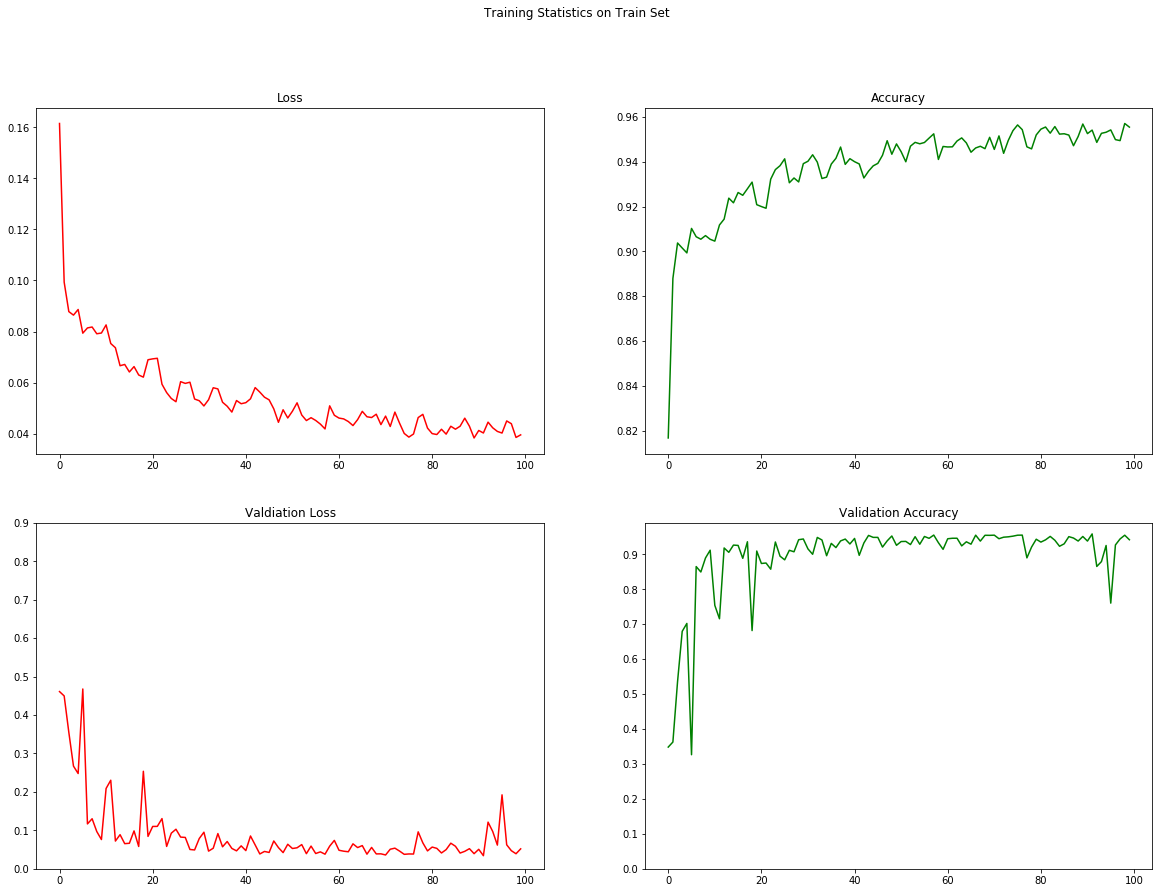

In [ ]:
plt.figure(figsize=(20, 14))
plt.suptitle('Training Statistics on Train Set')
plt.subplot(2,2,1)
plt.plot(hist.history['loss'], 'red')
plt.title('Loss')
plt.subplot(2,2,2)
plt.plot(hist.history['accuracy'], 'green')
plt.title('Accuracy')
plt.subplot(2,2,3)
plt.plot(hist.history['val_loss'], 'red')
plt.yticks(list(np.arange(0.0, 1.0, 0.10)))
plt.title('Valdiation Loss')
plt.subplot(2,2,4)
plt.plot(hist.history['val_accuracy'], 'green')
plt.yticks(list(np.arange(0.0, 1.0, 0.10)))
plt.title('Validation Accuracy')
plt.show()

We have trained the model on the **training set**.  
We will make predictions on the unseen **test set**

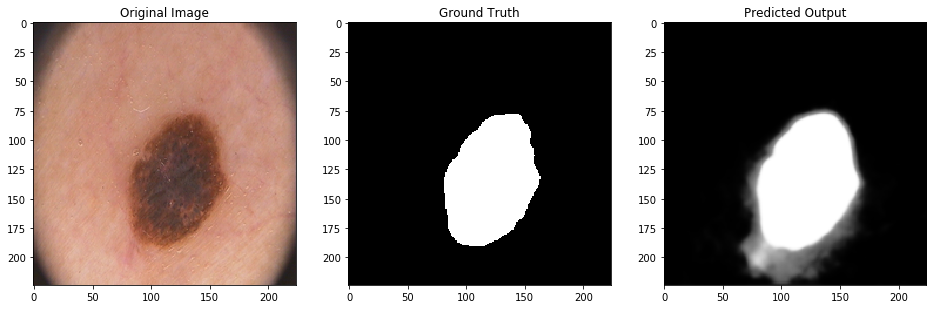

In [ ]:
img_num = 49
img_pred = model_1.predict(x_test[img_num].reshape(1,224,224,3))
plt.figure(figsize=(16,16))
plt.subplot(1,3,1)
plt.imshow(x_test[img_num])
plt.title('Original Image')
plt.subplot(1,3,2)
plt.imshow(y_test[img_num], plt.cm.binary_r)
plt.title('Ground Truth')
plt.subplot(1,3,3)
plt.imshow(img_pred.reshape(224, 224), plt.cm.binary_r)
plt.title('Predicted Output')
plt.show()

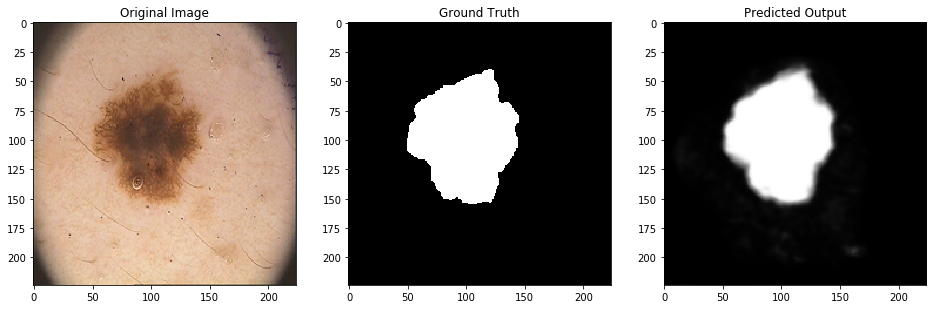

In [ ]:
img_num = 10
img_pred = model_1.predict(x_test[img_num].reshape(1,224,224,3))
plt.figure(figsize=(16,16))
plt.subplot(1,3,1)
plt.imshow(x_test[img_num])
plt.title('Original Image')
plt.subplot(1,3,2)
plt.imshow(y_test[img_num], plt.cm.binary_r)
plt.title('Ground Truth')
plt.subplot(1,3,3)
plt.imshow(img_pred.reshape(224,224), plt.cm.binary_r)
plt.title('Predicted Output')
plt.show()

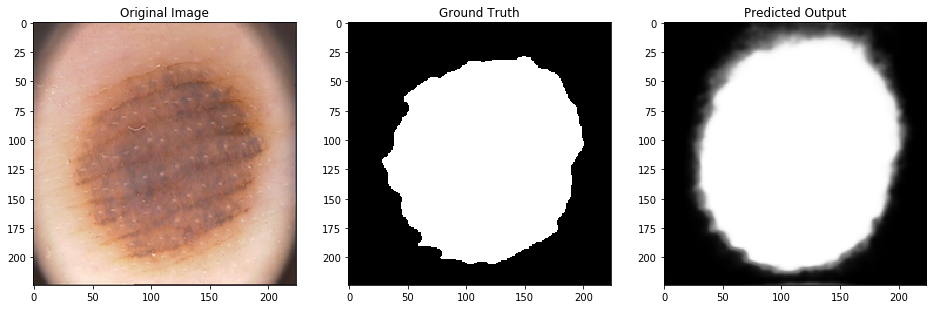

In [ ]:
img_num = 36
img_pred = model_1.predict(x_test[img_num].reshape(1,224,224,3))
plt.figure(figsize=(16,16))
plt.subplot(1,3,1)
plt.imshow(x_test[img_num])
plt.title('Original Image')
plt.subplot(1,3,2)
plt.imshow(y_test[img_num], plt.cm.binary_r)
plt.title('Ground Truth')
plt.subplot(1,3,3)
plt.imshow(img_pred.reshape(224,224), plt.cm.binary_r)
plt.title('Predicted Output')
plt.show()

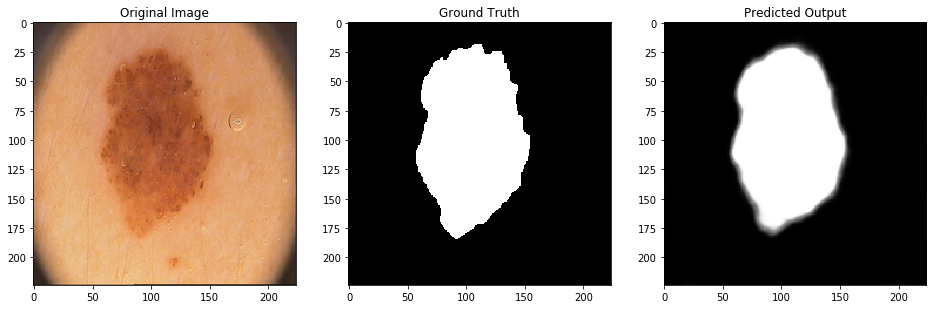

In [ ]:
img_num = 32
img_pred = model_1.predict(x_test[img_num].reshape(1,224,224,3))
plt.figure(figsize=(16,16))
plt.subplot(1,3,1)
plt.imshow(x_test[img_num])
plt.title('Original Image')
plt.subplot(1,3,2)
plt.imshow(y_test[img_num], plt.cm.binary_r)
plt.title('Ground Truth')
plt.subplot(1,3,3)
plt.imshow(img_pred.reshape(224,224), plt.cm.binary_r)
plt.title('Predicted Output')
plt.show()

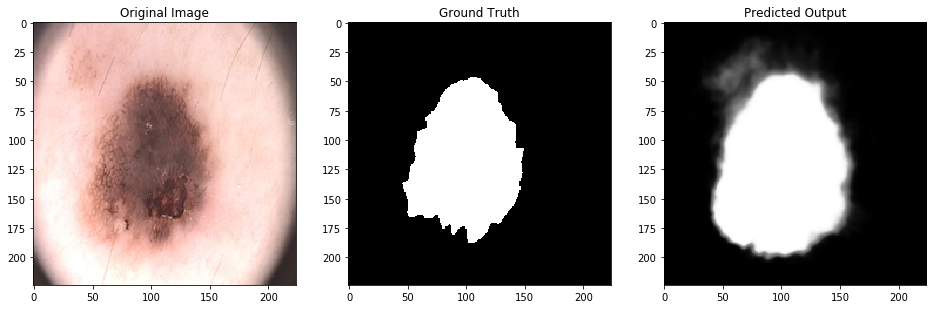

In [ ]:
img_num = 29
img_pred = model_1.predict(x_test[img_num].reshape(1,224,224,3))
plt.figure(figsize=(16,16))
plt.subplot(1,3,1)
plt.imshow(x_test[img_num])
plt.title('Original Image')
plt.subplot(1,3,2)
plt.imshow(y_test[img_num], plt.cm.binary_r)
plt.title('Ground Truth')
plt.subplot(1,3,3)
plt.imshow(img_pred.reshape(224,224), plt.cm.binary_r)
plt.title('Predicted Output')
plt.show()

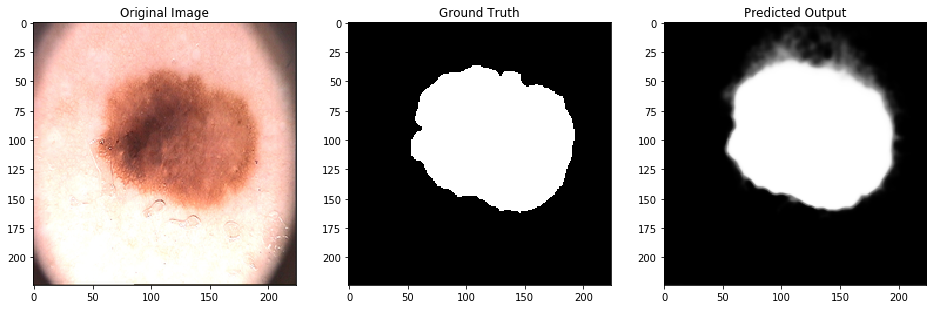

In [ ]:
img_num = 21
img_pred = model_1.predict(x_test[img_num].reshape(1,224,224,3))
plt.figure(figsize=(16,16))
plt.subplot(1,3,1)
plt.imshow(x_test[img_num])
plt.title('Original Image')
plt.subplot(1,3,2)
plt.imshow(y_test[img_num], plt.cm.binary_r)
plt.title('Ground Truth')
plt.subplot(1,3,3)
plt.imshow(img_pred.reshape(224,224), plt.cm.binary_r)
plt.title('Predicted Output')
plt.show()

## Final Enhance

* Currently the predicted outputs are blurry because the predicted pixel values are in the range 0 - 1.  
* To make clear edge preditions we can enhance our image by rounding up the pixel values to 1 which are > 0.5  .
* While rounding down the pixel values to 0 which are < 0.5.
* We can enhance the image to look for absolute shape predicted by ceiling and flooring the predicted values.

In [ ]:
def enhance(img):
    sub = (model_1.predict(img.reshape(1,224,224,3))).flatten()

    for i in range(len(sub)):
        if sub[i] > 0.5:
            sub[i] = 1
        else:
            sub[i] = 0
    return sub



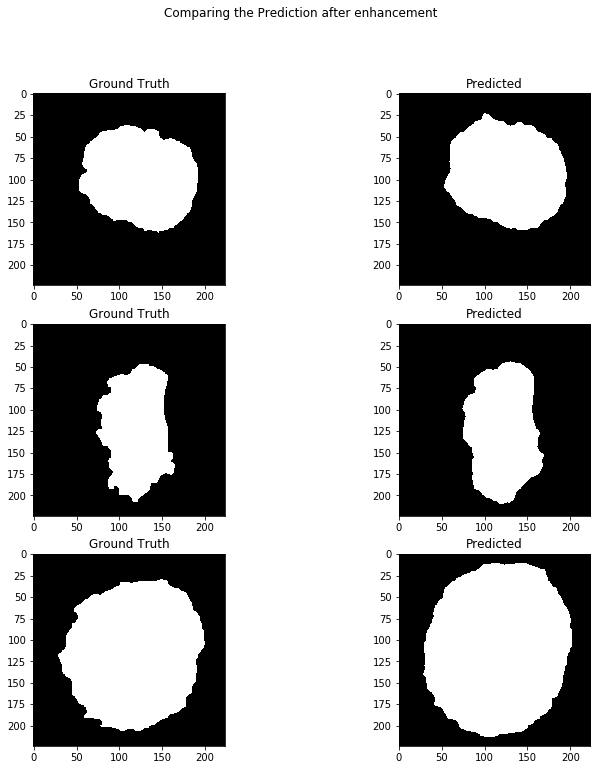

In [ ]:
plt.figure(figsize=(12,12))
plt.suptitle('Comparing the Prediction after enhancement')
plt.subplot(3,2,1)
plt.imshow(y_test[21],plt.cm.binary_r)
plt.title('Ground Truth')
plt.subplot(3,2,2)
plt.imshow(enhance(x_test[21]).reshape(224,224), plt.cm.binary_r)
plt.title('Predicted')
plt.subplot(3,2,3)
plt.imshow(y_test[47],plt.cm.binary_r)
plt.title('Ground Truth')
plt.subplot(3,2,4)
plt.imshow(enhance(x_test[47]).reshape(224,224), plt.cm.binary_r)
plt.title('Predicted')
plt.subplot(3,2,5)
plt.imshow(y_test[36],plt.cm.binary_r)
plt.title('Ground Truth')
plt.subplot(3,2,6)
plt.imshow(enhance(x_test[36]).reshape(224,224), plt.cm.binary_r)
plt.title('Predicted')
plt.show()

* So we can observe that our results are very good on the Test dataset which suggests that the model is quite robust and well performing too.

### **de nada!**